### Time to get your hands dirty! Can a computer learn if we're going to detect gravitational waves?

This episode of "time to get your hands dirty" is about something I studied carefully in the past: gravitational-wave selection effects. This is one the LIGO interferometers:

![](https://www.ligo.caltech.edu/system/news_items/images/53/page/Virgo_aerial_view_01.jpg?1506530275)


All experiments have selection effects. Some sources are easier to detect than others which distorts the population of sources we observe (this crucial in astronomy! Surveys are typically flux limited). 
In order to decided if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our selection effects (for instance: it would be wrong to say that all stars are close by just because we can't observe those that are very far!). In observational astronomy, this is known as [Malmquist bias](https://en.wikipedia.org/wiki/Malmquist_bias) and was first formulated in 1922.
 
**The goal here is to machine-learn the LIGO detectability: can we *predict* if a gravitational-wave source will be detected?**  

[This dataset](https://github.com/dgerosa/pdetclassifier/releases/download/v0.2/sample_2e7_design_precessing_higherordermodes_3detectors.h5) contains simulated gravitational-wave signals from merging black holes (careful the file size is >1 GB). If you've never seen them, the [.h5 format](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) is a highly optimized storage strategy for large datasets. It's amazing. In python, you can read it with `h5py`.

In particular, each source has the following features:
- `mtot`: the total mass of the binary
- `q`: the mass ratio
- `chi1x`, `chi1y`, `chi1z`, `chi2x`, `chi2y`, `chi2z`: the components of the black-hole spins in a suitable reference frame.
- `ra`, `dec`: the location of the source in the sky
- `iota`: the inclination of the orbital plane'
- `psi`: the polarization angle (gravitational waves have two polarization states much like light)
- `z`: the redshift

The detectability is defined using the `snr` (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network. Some (many?) of you will have studied this in Sesana's gravitational-wave course; [see here](https://arxiv.org/abs/1908.11170) for a nice write-up. All you need to know now is that we threshold the `snr` values and assume that LIGO will (not) see a source if `snr`>12 (`snr`<12). The resulting 0-1 labels are reported in the `det` attribute in the dataset.

Today's task is to train a classifier (you decide which one!) and separate sources that are detectables from those that aren't. 

Be creative! This is a challenge! Let's see who gets the  higher completeness and/or the smaller contamination (on a validation set, of course! Careful with overfitting here!).

*Tips*:
- You can downsample the data for debugging purposes
- You can also use only some of the features.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
data = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5')
data.keys()

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>

In [ ]:
#Taking only the data we plan to use! (Taking one every 5 cause my laptop dies otherwise)
det = np.array(data['det'])[::5] # 0 = not detected - 1 = detected
dec = np.array(data['dec'])[::5]
ra = np.array(data['ra'])[::5]
#iota = np.array(data['iota'])[::5] Negelcting the data we won't use.
#psi = np.array(data['psi'])[::5]
q = np.array(data['q'])[::5]
mtot = np.array(data['mtot'])[::5]
snr = np.array(data['snr'])[::5]
z = np.array(data['z'])[::5]

In [ ]:
#Giving it the proper shape for ML and taking only the well defined data
X = np.column_stack([dec, ra, z, q, mtot, snr])
X_clean = X[~np.isnan(X).any(axis=1)]
det_clean = det[~np.isnan(X).any(axis=1)]

In [6]:
#Our data has very different dimensions! let's scale it properly 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_clean)
X_clean = scaler.transform(X_clean)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_clean, det_clean, train_size=0.75, test_size=0.25)

First let's try with a decision tree! To try to make things faster let's apply a dim reduction first:

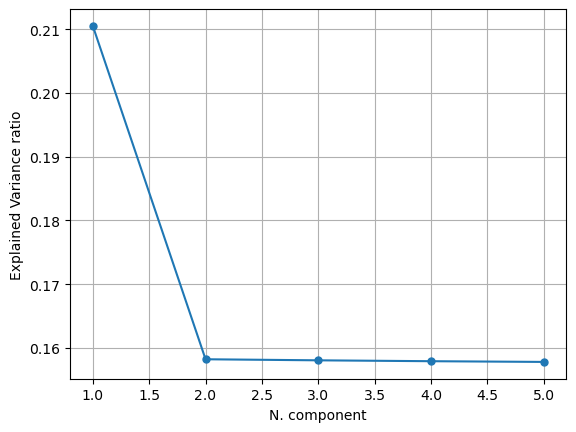

In [18]:
#To try and make things a bit faster, let's apply a dim reduction!
from sklearn.decomposition import PCA
myPCA = PCA(n_components=5) #From 7 down to 5 
myPCA.fit(X_train)
exp_var = myPCA.explained_variance_ratio_
comp = np.array([1,2,3,4,5])

plt.plot(comp, exp_var, marker = 'o', markersize = 5)
plt.xlabel('N. component')
plt.ylabel('Explained Variance ratio')
plt.grid()

In [19]:
new_X_train = myPCA.transform(X_train)
new_X_test = myPCA.transform(X_test)

In [20]:
print(f'{np.sum(myPCA.explained_variance_ratio_)*100:.2f}% of varainace explanied')

84.25% of varainace explanied


In [21]:
#Let's strat by trying a decision tree with Gini
from sklearn.tree import DecisionTreeClassifier
max_d = 4
DTC = DecisionTreeClassifier(criterion='gini', max_depth=max_d)
DTC.fit(new_X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [22]:
y_pred = DTC.predict(new_X_test)
y_prob = DTC.predict_proba(new_X_test)
from astroML.utils import completeness_contamination
compl, contam = completeness_contamination(y_pred, y_test)
print(f'Completeness = {compl:.3f}')
print(f'Contamination = {contam:.3f}')

Completeness = 0.428
Contamination = 0.328


Not so good! Let's see how we would have done with different depths:

In [23]:
from tqdm import tqdm
completeness = []
contamination = []

depth = np.arange(1, 11, 1)

for i in tqdm(depth):
    DTC = DecisionTreeClassifier(criterion='gini', max_depth=i)
    DTC.fit(new_X_train, y_train)
    y_pred = DTC.predict(new_X_test)
    compl, contam = completeness_contamination(y_pred, y_test)
    completeness.append(compl)
    contamination.append(contam)



100%|██████████| 10/10 [05:32<00:00, 33.20s/it]


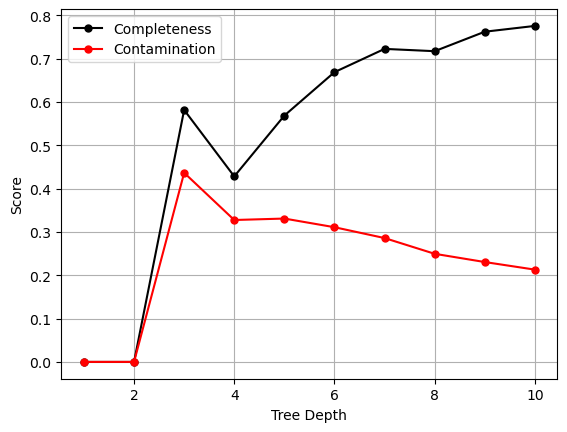

In [24]:
completeness = np.array(completeness)
contamination = np.array(contamination)

plt.plot(depth, completeness, 'o-k', markersize = 5, label='Completeness')
plt.plot(depth, contamination, 'o-r', markersize = 5, label='Contamination')
plt.xlabel('Tree Depth')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
#Computing the ROC curve for later with max_depth = 10:
from sklearn.metrics import roc_curve as ROC
from sklearn.metrics import precision_recall_curve as PRC

y_prob = DTC.predict_proba(new_X_test)

fpr_DT, tpr_DT, th_DT = ROC(y_test, y_prob[:,1])
pr_DT, acc_DT, th_DT = PRC(y_test, y_prob[:,1])

Not bad with max_depth = 10! But this took a while, let's see if random forest does better!

In [26]:
from sklearn.ensemble import RandomForestClassifier

myRFC = RandomForestClassifier(n_estimators=100,
                               criterion='gini', 
                               max_depth=9,
                               bootstrap=True,
                               n_jobs=-1,
                               verbose=1)

In [27]:
myRFC.fit(new_X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 10.1min finished


RandomForestClassifier(max_depth=9, n_jobs=-1, verbose=1)

In [28]:
y_prob = myRFC.predict_proba(new_X_test)
y_pred = myRFC.predict(new_X_test)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    2.2s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    5.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    4.5s finished


In [29]:
compl, contam = completeness_contamination(y_pred, y_test)
print(f'Completeness = {compl:.3f}')
print(f'Contamination = {contam:.3f}')

Completeness = 0.755
Contamination = 0.169


In [30]:
fpr_RF, tpr_RF, th_RF = ROC(y_test, y_prob[:,1])
pr_RF, acc_RF, th_RF = PRC(y_test, y_prob[:,1])

Let's try some bagging too!

In [31]:
from sklearn.ensemble import BaggingClassifier
myBC = BaggingClassifier(n_estimators=50, 
                         bootstrap=True, 
                         n_jobs=-1, 
                         verbose=1)

In [32]:
myBC.fit(new_X_train, y_train)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed: 14.8min remaining: 14.8min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed: 15.7min finished


BaggingClassifier(n_estimators=50, n_jobs=-1, verbose=1)

In [33]:
y_pred = myBC.predict(new_X_test)
y_prob = myBC.predict_proba(new_X_test)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:   19.5s remaining:   19.5s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:   21.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:   11.3s remaining:   11.3s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:   11.8s finished


In [34]:
compl, contam = completeness_contamination(y_pred, y_test)
print(f'Completeness = {compl:.3f}')
print(f'Contamination = {contam:.3f}')

Completeness = 0.833
Contamination = 0.135


In [35]:
fpr_BC, tpr_BC, th_BC = ROC(y_test, y_prob[:,1])
pr_BC, acc_BC, th_BC = PRC(y_test, y_prob[:,1])

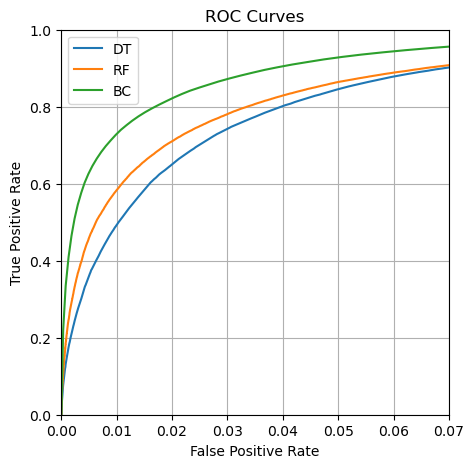

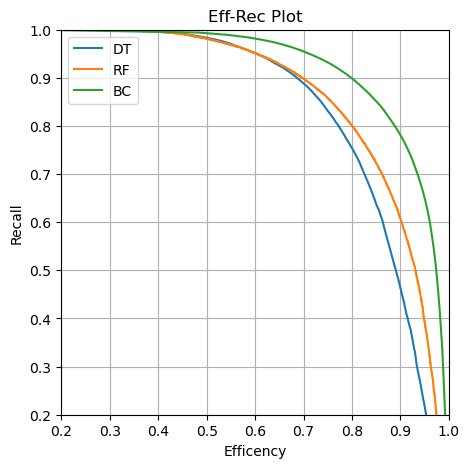

In [36]:
plt.figure(figsize=(5, 5))
plt.plot(fpr_DT, tpr_DT, label='DT')
plt.plot(fpr_RF, tpr_RF, label='RF')
plt.plot(fpr_BC, tpr_BC, label='BC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.xlim(0,0.07)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(pr_DT, acc_DT, label='DT')
plt.plot(pr_RF, acc_RF, label='RF')
plt.plot(pr_BC, acc_BC, label='BC')
plt.title('Eff-Rec Plot')
plt.xlabel('Efficency')
plt.ylabel('Recall')
plt.xlim(0.2,1)
plt.ylim(0.2,1)
plt.legend()
plt.grid(True)
plt.show()

From these plot and from the Completeness and Contamination we see that the Bagging Classifier is the one that performs the best!

Let's try to see what the confuzion matrix says when we use our whole data set:

In [37]:
from sklearn.metrics import confusion_matrix

new_X = myPCA.transform(X_clean)
y_tot_pred = myBC.predict(new_X)
conf_mat = confusion_matrix(det_clean, y_tot_pred)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:  1.1min remaining:  1.1min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  1.1min finished


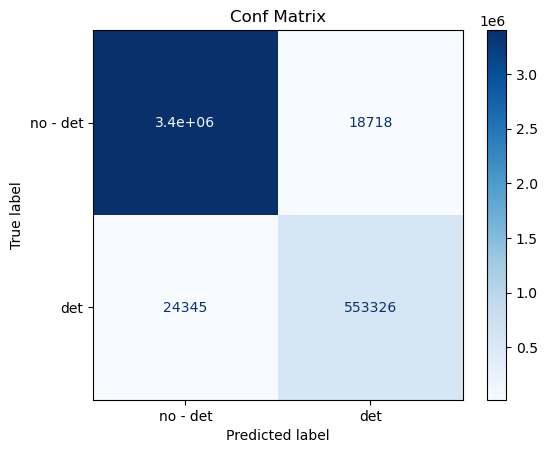

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=['no - det', 'det'])
disp.plot(cmap='Blues')
plt.title("Conf Matrix")
plt.show()

In [40]:
compl, contam = completeness_contamination(y_tot_pred, det_clean)
print(f'Completeness = {compl:.3f}')
print(f'Contamination = {contam:.3f}')

Completeness = 0.958
Contamination = 0.033


Not bad on our whole data set!